In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split , GridSearchCV

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet , BayesianRidge , SGDRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor , AdaBoostRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.kernel_ridge import KernelRidge
from catboost import CatBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.multioutput import MultiOutputRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
from sklearn.model_selection import cross_val_score
import numpy as np

In [21]:
df = pd.read_excel('C:/Users/yasmi/Downloads/logistic_data_v1.xlsx', engine='openpyxl')

df.head()

,K(MPa),epsilon_0,n,Umin(mm),Fmin(N),Uint(mm),Fint(N),Umax(mm),Fmax(N),pente1,pente2
0,400,0.001,0.15,0.24887,1085.258917,2.089109,1910.439714,10.572964,1943.394311,448.409721,3.884389
1,550,0.001,0.15,0.24887,1472.532116,2.065902,2625.373505,10.616330,2671.305527,634.464011,5.371898
2,700,0.001,0.15,0.24887,1865.863247,2.252145,3425.908793,12.616264,3395.272157,778.747499,-2.956029
3,850,0.001,0.15,0.24887,2246.508175,2.172331,4051.135133,10.790882,4125.089352,938.218597,8.580818
4,1000,0.001,0.15,0.24887,2619.809746,2.291147,4867.149496,12.508611,4847.925275,1100.408934,-1.881506


In [22]:
X= df.drop(columns = ['K(MPa)' , 'epsilon_0' , 'n'], axis=1)
y_K = df[["K(MPa)"]]
y_e = df[["epsilon_0"]]
y = df[["K(MPa)","epsilon_0","n"]]


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression":  Ridge(alpha=0.1, solver='saga', max_iter=100000),
    "Lasso Regression":  Lasso(alpha=0.001, max_iter=100000),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=100000),
    "Random Forest": MultiOutputRegressor(RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)),
    "Gradient Boosting": MultiOutputRegressor(GradientBoostingRegressor(learning_rate=0.05, n_estimators=200, random_state=42)),
    "XGBoost": MultiOutputRegressor(XGBRegressor(learning_rate=0.05, max_depth=6, n_estimators=200, random_state=42)),
    "LightGBM": MultiOutputRegressor(LGBMRegressor(n_estimators=1000,learning_rate=0.01,num_leaves=31,min_data_in_leaf=1,min_gain_to_split=0.0,verbose=-1)),
    "CatBoost": CatBoostRegressor(loss_function='MultiRMSE', iterations=1000, depth=6, learning_rate=0.05, random_seed=42, verbose=0)
}

In [25]:
models.keys()

dict_keys(['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'ElasticNet', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'LightGBM', 'CatBoost'])

In [26]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if isinstance(y_pred, np.ndarray) and y_pred.ndim == 1:
        y_pred = y_pred.reshape(-1, 1)

    r2_scores = []
    mse_scores = []
    for i in range(y.shape[1]):
        r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
        mse = mean_squared_error(y_test.iloc[:, i], y_pred[:, i])
        r2_scores.append(r2)
        mse_scores.append(mse)

    results.append({
        "Model": name,
        "R² (mean)": np.mean(r2_scores),
        "MSE (mean)": np.mean(mse_scores),
        "R² per target": r2_scores,
        "MSE per target": mse_scores
    })

In [27]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="R² (mean)", ascending=False)

print(results_df[["Model", "R² (mean)", "MSE (mean)"]])

               Model  R² (mean)   MSE (mean)
8           CatBoost   0.968556   403.272678
4      Random Forest   0.963332   735.790372
5  Gradient Boosting   0.959659   969.544955
0  Linear Regression   0.956003   331.026830
6            XGBoost   0.913395  1700.173538
3         ElasticNet   0.906009   331.529756
2   Lasso Regression   0.903504   331.036212
1   Ridge Regression   0.881367   364.400095
7           LightGBM   0.873144  2099.869251


In [28]:
for index, row in results_df.iterrows():
    print(f"\nModel: {row['Model']}")
    for i, col in enumerate(y.columns):
        print(f"  {col} - R²: {row['R² per target'][i]}, MSE: {row['MSE per target'][i]}")


Model: CatBoost
  K(MPa) - R²: 0.9654968651821684, MSE: 1209.8179192524499
  epsilon_0 - R²: 0.9619955959857509, MSE: 1.8878155632422018e-06
  n - R²: 0.9781756537030483, MSE: 0.00011348660074414924

Model: Random Forest
  K(MPa) - R²: 0.9370473676705453, MSE: 2207.3711
  epsilon_0 - R²: 0.9554120740471576, MSE: 2.214842798611113e-06
  n - R²: 0.9975360576923079, MSE: 1.2812499999998977e-05

Model: Gradient Boosting
  K(MPa) - R²: 0.9170478307334516, MSE: 2908.6348631622513
  epsilon_0 - R²: 0.9619283464751169, MSE: 1.891156088533634e-06
  n - R²: 0.9999999987343908, MSE: 6.581167658446458e-12

Model: Linear Regression
  K(MPa) - R²: 0.9716780670557981, MSE: 993.080256755497
  epsilon_0 - R²: 0.9404329738411206, MSE: 2.9589086306057123e-06
  n - R²: 0.9558984963417864, MSE: 0.00022932781902271088

Model: XGBoost
  K(MPa) - R²: 0.8545368313789368, MSE: 5100.5205078125
  epsilon_0 - R²: 0.9048796751216237, MSE: 4.724968969878511e-06
  n - R²: 0.9807684294472783, MSE: 0.00010000416687415

In [29]:
#modell = CatBoostRegressor(loss_function='MultiRMSE', iterations=1000, depth=6, learning_rate=0.05, random_seed=42, verbose=0)
#modell = LinearRegression()
# modell =   Ridge(alpha=0.1, solver='saga', max_iter=100000)
# modell =  Lasso(alpha=0.001, max_iter=100000)
# modell =  ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=100000)
#modell =  MultiOutputRegressor(RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42))
#modell =  MultiOutputRegressor(GradientBoostingRegressor(learning_rate=0.05, n_estimators=200, random_state=42))
#modell =  MultiOutputRegressor(XGBRegressor(learning_rate=0.05, max_depth=6, n_estimators=200, random_state=42))
# modell = MultiOutputRegressor(LGBMRegressor(n_estimators=1000,learning_rate=0.01,num_leaves=31,min_data_in_leaf=1,min_gain_to_split=0.0,verbose=-1))
modell =  CatBoostRegressor(loss_function='MultiRMSE', iterations=1000, depth=6, learning_rate=0.05, random_seed=42, verbose=0)

In [30]:
model = CatBoostRegressor(loss_function='MultiRMSE', iterations=1000, depth=6, learning_rate=0.05, random_seed=42, verbose=0)

In [31]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.utils import resample
from sklearn.multioutput import MultiOutputRegressor


n_iterations = 100  # nombre d’échantillons bootstrap
test_idx = 0        # index du point de test
predictions = []
for i in range(n_iterations):
    X_resample, y_resample = resample(X_train, y_train)
    
    model.fit(X_resample, y_resample)
    
    y_pred = model.predict(X_test[test_idx:test_idx+1])
    predictions.append(y_pred[0])  

predictions = np.array(predictions)

lower = np.percentile(predictions, 2.5, axis=0)
upper = np.percentile(predictions, 97.5, axis=0)
mean_pred = predictions.mean(axis=0)

params = ['K', 'ep', 'n']
for i in range(3):
    print(f"{params[i]}: {mean_pred[i]:.3f} (95% CI: {lower[i]:.3f} – {upper[i]:.3f})")

# Le code :

# réentraîne un modèle 100 fois sur des versions bootstrappées du jeu d’apprentissage,

# fait 100 prédictions pour un même point de test,

# calcule la moyenne et l’IC95% pour quantifier l’incertitude sur K, ep et n.

K: 893.561 (95% CI: 841.563 – 954.348)
ep: 0.016 (95% CI: 0.013 – 0.019)
n: 0.160 (95% CI: 0.151 – 0.178)


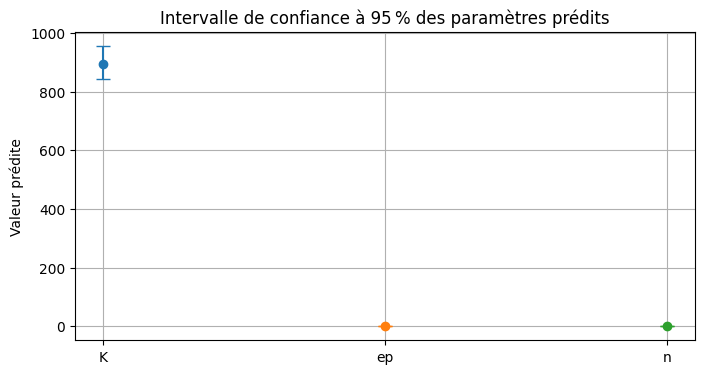

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
for i, param in enumerate(params):
    plt.errorbar(i, mean_pred[i], yerr=[[mean_pred[i]-lower[i]], [upper[i]-mean_pred[i]]], fmt='o', capsize=5, label=param)

plt.xticks(range(3), params)
plt.title("Intervalle de confiance à 95 % des paramètres prédits")
plt.ylabel("Valeur prédite")
plt.grid(True)
plt.show()


K: 893.561 (95% CI: 841.563 – 954.348)


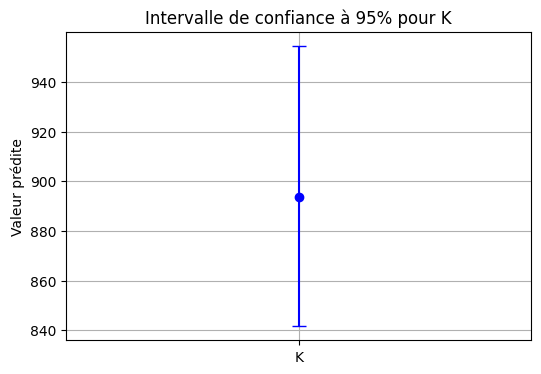

ep: 0.016 (95% CI: 0.013 – 0.019)


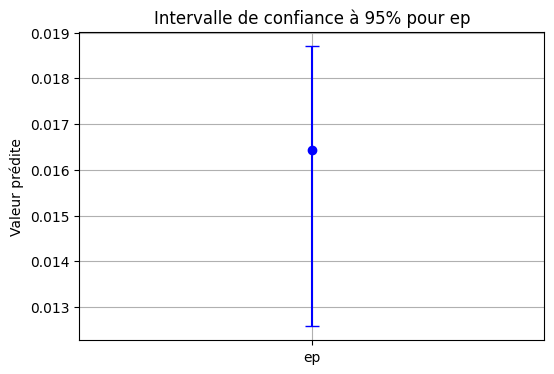

n: 0.160 (95% CI: 0.151 – 0.178)


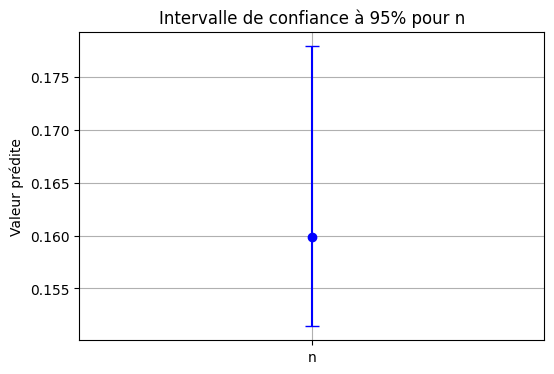

In [33]:
# import numpy as np
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.utils import resample
# from sklearn.multioutput import MultiOutputRegressor
# import matplotlib.pyplot as plt

# n_iterations = 100  # nombre d’échantillons bootstrap
# test_idx = 0        # index du point de test
# predictions = []

# for i in range(n_iterations):
#     X_resample, y_resample = resample(X_train, y_train)
#     model.fit(X_resample, y_resample)
#     y_pred = model.predict(X_test[test_idx:test_idx+1])
#     predictions.append(y_pred[0])

# predictions = np.array(predictions)

# lower = np.percentile(predictions, 2.5, axis=0)
# upper = np.percentile(predictions, 97.5, axis=0)
# mean_pred = predictions.mean(axis=0)

# params = ['K', 'ep', 'n']

# Affichage séparé pour chaque paramètre
for i, param in enumerate(params):
    print(f"{param}: {mean_pred[i]:.3f} (95% CI: {lower[i]:.3f} – {upper[i]:.3f})")
    
    plt.figure(figsize=(6,4))
    plt.errorbar(0, mean_pred[i], 
                 yerr=[[mean_pred[i]-lower[i]], [upper[i]-mean_pred[i]]],
                 fmt='o', capsize=5, color="blue")
    plt.xticks([0], [param])
    plt.title(f"Intervalle de confiance à 95% pour {param}")
    plt.ylabel("Valeur prédite")
    plt.grid(True)
    plt.show()


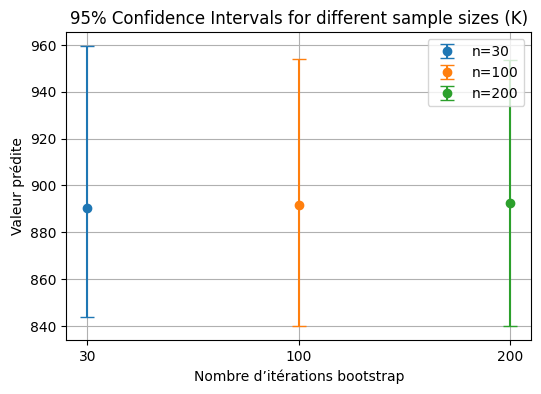

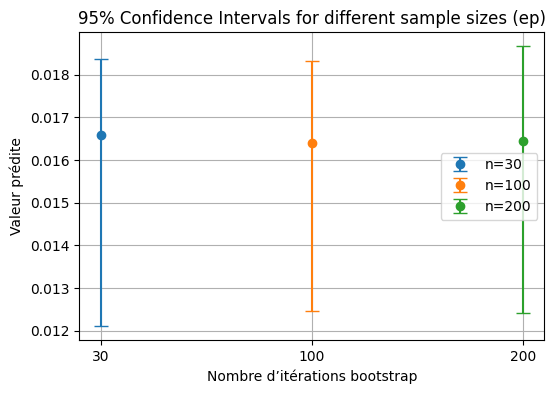

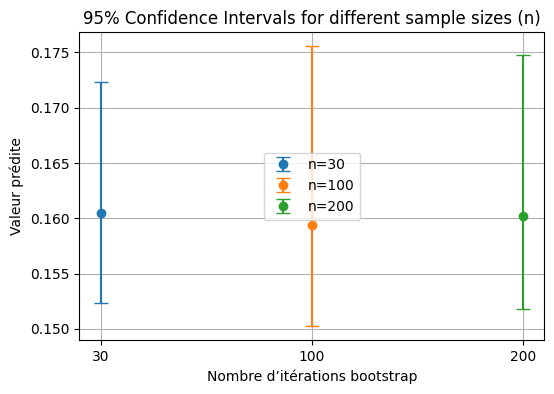

In [37]:
import numpy as np
from sklearn.utils import resample
import matplotlib.pyplot as plt

# tailles d'échantillons bootstrap à tester
sample_sizes = [30, 100, 200]

params = ['K', 'ep', 'n']

results = {s: {} for s in sample_sizes}

# Boucle sur les tailles de bootstrap
for n_iterations in sample_sizes:
    predictions = []
    for i in range(n_iterations):
        X_resample, y_resample = resample(X_train, y_train)
        model.fit(X_resample, y_resample)
        y_pred = model.predict(X_test[0:1])
        predictions.append(y_pred[0])
    
    predictions = np.array(predictions)
    
    # Calcul des bornes et de la moyenne
    lower = np.percentile(predictions, 2.5, axis=0)
    upper = np.percentile(predictions, 97.5, axis=0)
    mean_pred = predictions.mean(axis=0)
    
    # Stockage des résultats
    for i, param in enumerate(params):
        results[n_iterations][param] = (mean_pred[i], lower[i], upper[i])

# --- Visualisation : une figure par paramètre ---
for i, param in enumerate(params):
    plt.figure(figsize=(6,4))
    for j, n_iter in enumerate(sample_sizes):
        mean_pred, lower, upper = results[n_iter][param]
        plt.errorbar(j, mean_pred,
                     yerr=[[mean_pred-lower], [upper-mean_pred]],
                     fmt='o', capsize=5, label=f"n={n_iter}")
    
    plt.xticks(range(len(sample_sizes)), [f"{n}" for n in sample_sizes])
    plt.title(f"95% Confidence Intervals for different sample sizes ({param})")
    plt.ylabel("Valeur prédite")
    plt.xlabel("Nombre d’itérations bootstrap")
    plt.grid(True)
    plt.legend()
    plt.show()


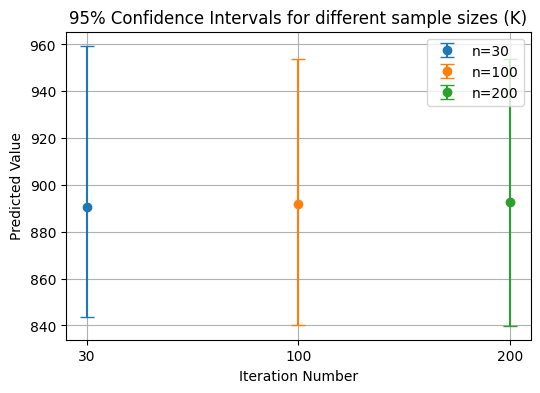

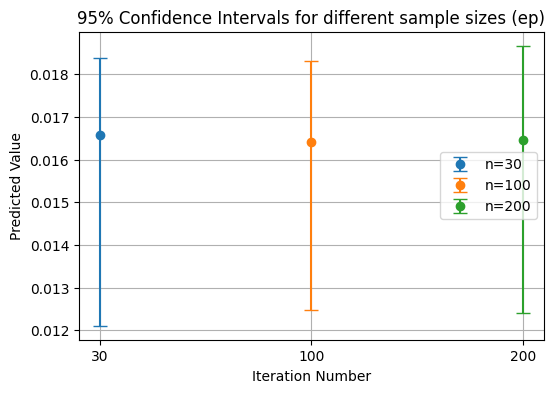

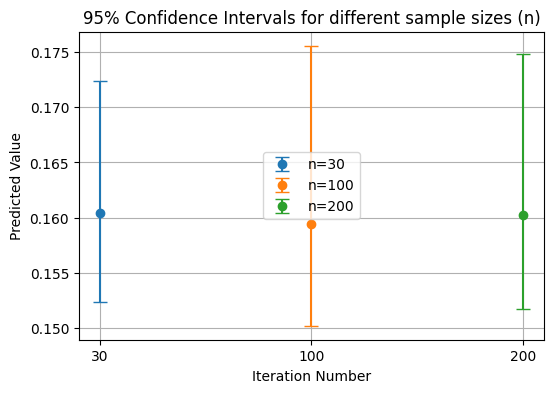

In [38]:
# --- Visualisation : une figure par paramètre ---
for i, param in enumerate(params):
    plt.figure(figsize=(6,4))
    for j, n_iter in enumerate(sample_sizes):
        mean_pred, lower, upper = results[n_iter][param]
        plt.errorbar(j, mean_pred,
                     yerr=[[mean_pred-lower], [upper-mean_pred]],
                     fmt='o', capsize=5, label=f"n={n_iter}")
    
    plt.xticks(range(len(sample_sizes)), [f"{n}" for n in sample_sizes])
    plt.title(f"95% Confidence Intervals for different sample sizes ({param})")
    plt.ylabel("Predicted Value")
    plt.xlabel("Iteration Number")
    plt.grid(True)
    plt.legend()
    plt.show()


In [35]:
from sklearn.model_selection import KFold
import numpy as np

X_array = X.values if hasattr(X, "values") else X
y_array = y.values if hasattr(y, "values") else y

kf = KFold(n_splits=3, shuffle=True, random_state=42)
predictions = []
true_values = []

model = CatBoostRegressor(loss_function='MultiRMSE', iterations=1000, depth=6, learning_rate=0.05, random_seed=42, verbose=0)

for train_idx, test_idx in kf.split(X_array):
    model.fit(X_array[train_idx], y_array[train_idx])
    y_pred = model.predict(X_array[test_idx])
    
    predictions.append(y_pred)
    true_values.append(y_array[test_idx])

predictions = np.vstack(predictions)
true_values = np.vstack(true_values)

means = predictions.mean(axis=0)
stds = predictions.std(axis=0)

params = ['K', 'eps', 'n']
for i in range(len(params)):
    print(f"{params[i]}: {means[i]:.3f} ± {stds[i]:.3f}")

K: 699.356 ± 198.358
eps: 0.011 ± 0.006
n: 0.251 ± 0.066


In [36]:
from sklearn.utils import resample

n_iterations = 100
params_boot = []

for i in range(n_iterations):
    X_resampled, y_resampled = resample(X_train, y_train)
    model.fit(X_resampled, y_resampled)
    y_pred = model.predict(X_test)
    params_boot.append(y_pred)

params_boot = np.array(params_boot)

lower_bound = np.percentile(params_boot[:, 0, :], 2.5, axis=0)
upper_bound = np.percentile(params_boot[:, 0, :], 97.5, axis=0)


In [ ]:
upper_bound

In [ ]:
lower_bound

In [ ]:
df_test25 = pd.read_excel("C:/Users/yasmi/Downloads/Indices de forme (3).xlsx", engine='openpyxl' , sheet_name="25")
df_test25.head()

In [ ]:
predictions = {}

modell.fit(X_train, y_train)
y_pred = modell.predict(df_test25)

predictions["25"] = y_pred.flatten()

print("\nPredictions for temperature = 25")
print("  K (MPa):", predictions["25"][0], "epsilon_0:", predictions["25"][1], "n:", predictions["25"][2])


In [ ]:
df_test100 = pd.read_excel("C:/Users/yasmi/Downloads/Indices de forme (3).xlsx", engine='openpyxl' , sheet_name="100")
df_test100.head()

In [ ]:
modell.fit(X_train, y_train)
y_pred = modell.predict(df_test100)

predictions["100"] = y_pred.flatten()

print("\nPredictions for temperature = 100")
print("  K (MPa):", predictions["100"][0], "epsilon_0:", predictions["100"][1], "n:", predictions["100"][2])

In [ ]:
df_test150 = pd.read_excel("C:/Users/yasmi/Downloads/Indices de forme (3).xlsx", engine='openpyxl' , sheet_name="150")
df_test150.head()

In [ ]:
modell.fit(X_train, y_train)
y_pred = modell.predict(df_test150)

predictions["150"] = y_pred.flatten()

print("\nPredictions for temperature = 150")
print("  K (MPa):", predictions["150"][0], "epsilon_0:", predictions["150"][1], "n:", predictions["150"][2])

In [ ]:
df_test200 = pd.read_excel("C:/Users/yasmi/Downloads/Indices de forme (3).xlsx", engine='openpyxl' , sheet_name="200")
df_test200.head()

In [ ]:
modell.fit(X_train, y_train)
y_pred = modell.predict(df_test200)

predictions["200"] = y_pred.flatten()

print("\nPredictions for temperature = 200")
print("  K (MPa):", predictions["200"][0], "epsilon_0:", predictions["200"][1], "n:", predictions["200"][2])

In [ ]:
predictions